In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Upload de dados

In [4]:
train = pd.read_csv("train.csv")

train

,resp_text,clarity
0,"Prezado(a) Senhor(a), Esclarecemos que o Se...",c5
1,"Prezada cidadã, As informações sobre óbitos ...",c1
2,"Prezado Senhor Julio, A Ouvidoria-Geral da P...",c1
3,"Prezado(a) Senhor(a), Esclarecemos que o Se...",c234
4,"Senhor, O Serviço de Informações ao Cidadão d...",c234
...,...,...
20087,Prezado Sr. Luciano Wolff A sua solicitação ...,c1
20088,"PREZADO CIDADãO, A COORDENAçãO DO PROGRAMA FA...",c1
20089,"Prezado, Informamos que o Ministério da Agr...",c1
20090,"Prezado Senhor, Encaminhamos em anexo respos...",c1


In [8]:
train["clarity"].value_counts().reset_index().sort_values("count", ascending=False)

,clarity,count
0,c5,6892
1,c234,6853
2,c1,6347


In [26]:
train.isnull().sum()

resp_text             0
clarity               0
words_in_resp_text    0
dtype: int64

# 2. Engenharia de Features

## 2.1 Numero de palavras

(array([1.4853e+04, 3.8200e+03, 9.3100e+02, 2.7500e+02, 1.0300e+02,
        6.8000e+01, 2.5000e+01, 7.0000e+00, 7.0000e+00, 3.0000e+00]),
 array([1.000e+00, 1.830e+02, 3.650e+02, 5.470e+02, 7.290e+02, 9.110e+02,
        1.093e+03, 1.275e+03, 1.457e+03, 1.639e+03, 1.821e+03]),
 <BarContainer object of 10 artists>)

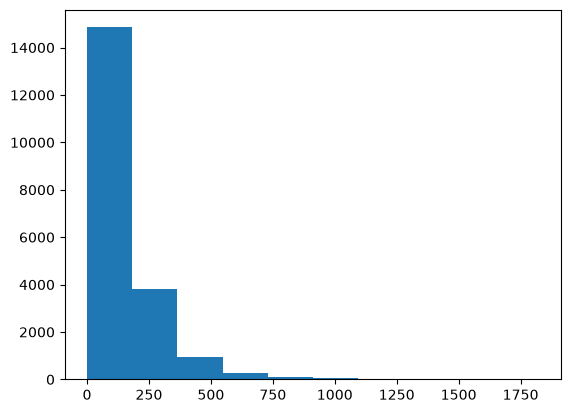

In [17]:
train["words_in_resp_text"] = train["resp_text"].str.split().str.len()
plt.hist(train["words_in_resp_text"])

In [22]:
trainC1 = train[train["clarity"] == "c1"]
trainC234 = train[train["clarity"] == "c234"]
trainC5 = train[train["clarity"] == "c5"]

(array([3.901e+03, 1.668e+03, 4.820e+02, 1.550e+02, 7.400e+01, 2.600e+01,
        3.100e+01, 7.000e+00, 1.000e+00, 2.000e+00]),
 array([1.000e+00, 1.490e+02, 2.970e+02, 4.450e+02, 5.930e+02, 7.410e+02,
        8.890e+02, 1.037e+03, 1.185e+03, 1.333e+03, 1.481e+03]),
 <BarContainer object of 10 artists>)

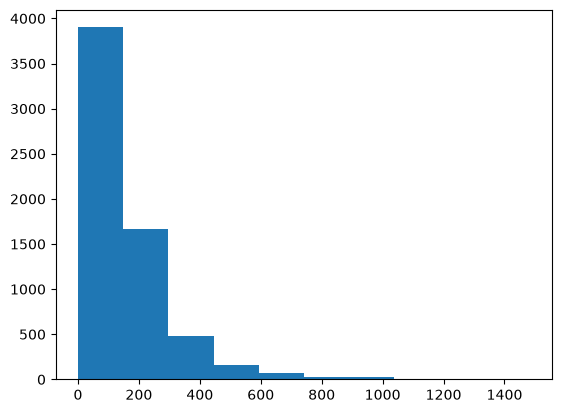

In [23]:
plt.hist(trainC1["words_in_resp_text"])

(array([4.801e+03, 1.476e+03, 3.770e+02, 1.160e+02, 4.200e+01, 2.300e+01,
        1.100e+01, 1.000e+00, 5.000e+00, 1.000e+00]),
 array([1.000e+00, 1.830e+02, 3.650e+02, 5.470e+02, 7.290e+02, 9.110e+02,
        1.093e+03, 1.275e+03, 1.457e+03, 1.639e+03, 1.821e+03]),
 <BarContainer object of 10 artists>)

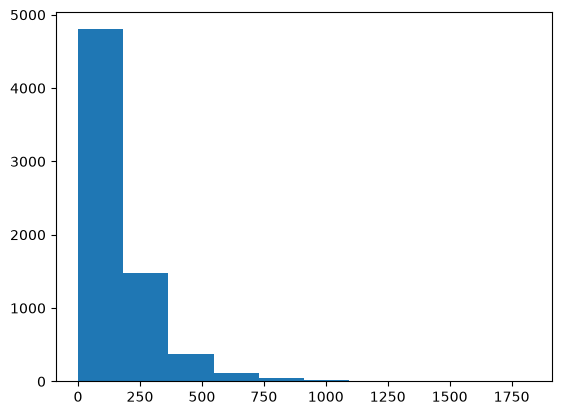

In [24]:
plt.hist(trainC234["words_in_resp_text"])

(array([5.450e+03, 1.083e+03, 2.380e+02, 6.000e+01, 2.000e+01, 2.400e+01,
        8.000e+00, 6.000e+00, 1.000e+00, 2.000e+00]),
 array([1.0000e+00, 1.7720e+02, 3.5340e+02, 5.2960e+02, 7.0580e+02,
        8.8200e+02, 1.0582e+03, 1.2344e+03, 1.4106e+03, 1.5868e+03,
        1.7630e+03]),
 <BarContainer object of 10 artists>)

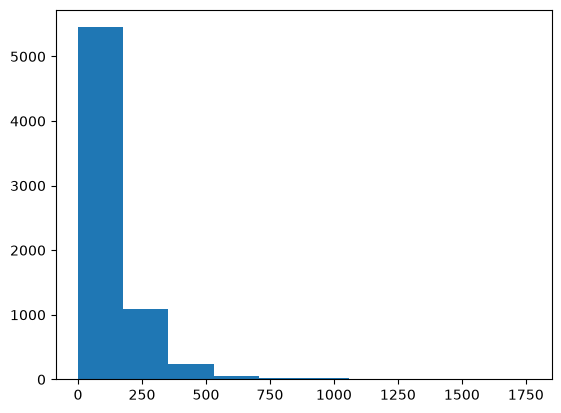

In [25]:
plt.hist(trainC5["words_in_resp_text"])

Conclusão: quantidade de palavras não pode ser usada como uma feature pois tem distribuição parecida em todas as categorias

In [8]:
train.duplicated(subset='resp_text', keep=False).value_counts()

False    17969
True      2123
Name: count, dtype: int64

In [9]:
train.duplicated().value_counts()

False    18813
True      1279
Name: count, dtype: int64

In [18]:
train_noSameClassDuplicates = train.drop_duplicates()

train_noSameClassDuplicates.duplicated(subset="resp_text", keep=False).value_counts()
train_noSameClassDuplicates.to_csv("train_noSameClassDuplicates.csv")

In [41]:
train_noDuplicates = train_noSameClassDuplicates

train_noDuplicates["duplicatedText"] = train_noDuplicates.duplicated(subset="resp_text", keep=False)

train_DuplicatesMultipleClasses = train_noDuplicates[train_noDuplicates["duplicatedText"]]

grouped = train_DuplicatesMultipleClasses.groupby('resp_text')['clarity'].apply(set).reset_index()

count_c1_c234 = grouped['clarity'].apply(lambda x: {'c1', 'c234'}.issubset(x)).sum()
count_c234_c5 = grouped['clarity'].apply(lambda x: {'c234', 'c5'}.issubset(x)).sum()
count_c1_c5 = grouped['clarity'].apply(lambda x: {'c1', 'c5'}.issubset(x)).sum()

# 3. Create a clean summary table
summary_df = pd.DataFrame({
    'Intersection': ['c1 & c234', 'c234 & c5', 'c1 & c5'],
    'Total Duplicates': [count_c1_c234, count_c234_c5, count_c1_c5]
})

print(summary_df)

  Intersection  Total Duplicates
0    c1 & c234               182
1    c234 & c5               142
2      c1 & c5               147


In [48]:
# 1. Group by the text to find which sets of classes each text belongs to
grouped = train_noSameClassDuplicates.groupby('resp_text')['clarity'].apply(set).reset_index()

# 2. Identify the overlapping item_ids (the resp_texts)
items_c1_c5 = grouped[grouped['clarity'].apply(lambda x: {'c1', 'c5'}.issubset(x))]['resp_text']
items_c1_c234 = grouped[grouped['clarity'].apply(lambda x: {'c1', 'c234'}.issubset(x))]['resp_text']
items_c234_c5 = grouped[grouped['clarity'].apply(lambda x: {'c234', 'c5'}.issubset(x))]['resp_text']

# Print the counts for verification
print(f"Items in c1 & c5: {len(items_c1_c5)}")
print(f"Items in c1 & c234: {len(items_c1_c234)}")
print(f"Items in c234 & c5: {len(items_c234_c5)}")

# 3. Combine items to transform (excluding any that are also in the drop list)
items_to_transform = set(items_c1_c234).union(set(items_c234_c5)) - set(items_c1_c5)

# 4. Drop all observations for items in the c1 & c5 group
train_noDuplicates = train_noSameClassDuplicates[~train_noSameClassDuplicates['resp_text'].isin(items_c1_c5)].copy()

# 5. Transform all observations for the remaining target items to 'c234'
train_noDuplicates.loc[train_noDuplicates['resp_text'].isin(items_to_transform), 'clarity'] = 'c234'

# 6. Drop duplicates so you don't end up with two identical 'c234' rows for the same text
# Dropping based on 'resp_text' and 'clarity' ignores the 'Unnamed: 0' index column differences
train_noDuplicates = train_noDuplicates.drop_duplicates(subset=['resp_text', 'clarity'])

# View the size difference
print(f"\nOriginal rows: {len(train_noSameClassDuplicates)}")
print(f"New rows: {len(train_noDuplicates)}")

train_noDuplicates.to_csv("train_noDuplicates.csv")

Items in c1 & c5: 147
Items in c1 & c234: 182
Items in c234 & c5: 142

Original rows: 18813
New rows: 18285
